In [103]:
import h5py
import numpy as np
from util import plot_corner

In [105]:
with h5py.File('/home/noah.wolfe/lvk-data/GWTC-4/RP/BBHMassSpinRedshift_BrokenPowerLawTwoPeaks_GaussianComponentSpins_PowerLawRedshift.h5', 'r') as f:
    keys = list(f.attrs['hyperparameters'])
    o4a_samples = dict(zip(
        keys,
        f['posterior']['hyperparameter_samples'][:].T
    ))

for key in list(o4a_samples.keys()):
    if key[:5] == 'ln_bf':
        o4a_samples.pop(key)
    if key[:4] == 'var_':
        o4a_samples.pop(key)

In [17]:
samples.keys()

dict_keys(['alpha_1', 'alpha_2', 'alpha_chi', 'amax', 'beta', 'beta_chi', 'break_mass', 'delta_m_1', 'delta_m_2', 'lam_0', 'lam_1', 'lamb', 'log_10_rate', 'log_likelihood', 'log_prior', 'mlow_1', 'mlow_2', 'mmax', 'mpp_1', 'mpp_2', 'mu_chi', 'mu_spin', 'pdet_n_effective', 'rate', 'selection', 'selection_variance', 'sigma_chi', 'sigma_spin', 'sigpp_1', 'sigpp_2', 'surveyed_hypervolume', 'variance', 'xi_spin'])

In [71]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import matplotlib.pyplot as plt

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

from data import get_posteriors
from data import get_injections

from bilby_util import convert_bilby_prior 

from models import bpl2p_plz_truncnormmag_isogausstilt as model

from likelihood import unravel
from likelihood import get_log_probs

from flows import default_flow
from variational import fit

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
posteriors, events = get_posteriors(load=True)
injections = get_injections(load=True)

if 'mass_1_source' in posteriors.keys():
    posteriors['mass_1'] = posteriors.pop('mass_1_source')

injections = get_injections(load=True)
injections['total_generated'] = injections.pop('total')
if 'mass_1_source' in injections.keys():
    injections['mass_1'] = injections.pop('mass_1_source')

In [72]:
param_keys, bounds, log_prior, fold = convert_bilby_prior('./priors/lvk.prior')

In [73]:
def transform(x):
    x = unravel(param_keys, x)
    return fold(x)

In [74]:
log_likelihood, log_target = get_log_probs(
    posteriors,
    injections,
    model,
    log_prior,
    transform=transform
)

In [75]:
flow_init = default_flow(jax.random.key(1), bounds)

In [76]:
flow, loss = fit(
    jax.random.key(2),
    flow_init,
    lambda x: log_prior(transform(x)),
    clip=False,
    lr=1,
    batch_size=10_000,
    steps=1_000
)

train: 100%|██████████| 1000/1000 [00:10<00:00, 96.12it/s]


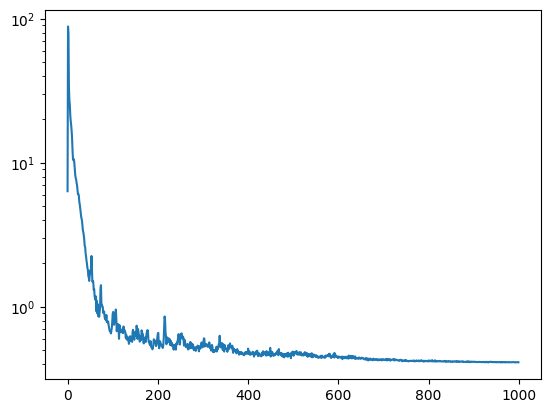

In [77]:
fig, ax = plt.subplots()
ax.plot(loss)
ax.set_yscale('log')

In [78]:
samples, _ = flow.sample_and_log_prob(jax.random.key(1), (10_000,))

In [79]:
samples = jax.vmap(transform)(samples)

In [80]:
from bilby.core.prior import ConditionalPriorDict
prior_samples = ConditionalPriorDict('./priors/lvk.prior').sample(10_000)

12:20 bilby WARNING : Prior sampling efficiency is very low, please verify its validity.


In [81]:
prior_samples['lam_2'] = 1 - prior_samples['lam_1'] - prior_samples['lam_0']

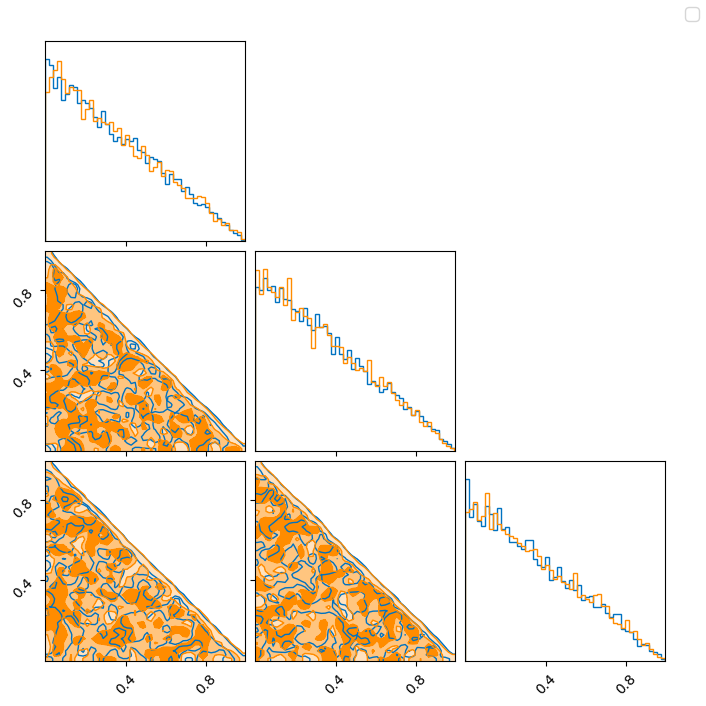

In [83]:
import numpy as np
from util import plot_multiple 

plot_keys = ['lam_0', 'lam_1', 'lam_2']

fig = plot_multiple(
    [np.column_stack([prior_samples[k] for k in plot_keys]),
    np.column_stack([samples[k] for k in plot_keys])]
)

In [94]:
flow, loss = fit(
    jax.random.key(2),
    flow,
    log_target,
    clip=True,
    lr=1e-1,
    batch_size=1,
    steps=10_000
)

train: 100%|██████████| 10000/10000 [03:43<00:00, 44.82it/s]


(1041.755746714999, 1092.755746714999)

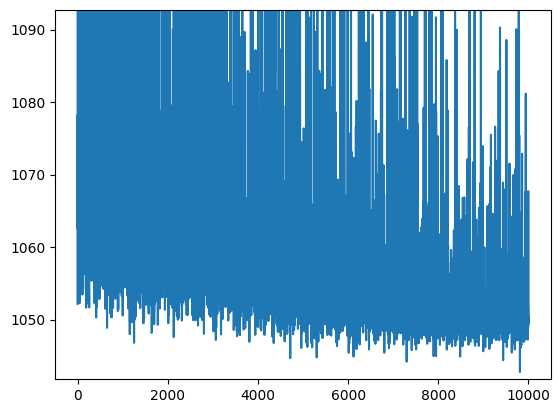

In [96]:
fig, ax = plt.subplots()
ax.plot(range(10_000), loss)
#ax.set_yscale('log')
ax.set_ylim(loss.min() - 1, loss.min() + 50)

In [97]:
from variational import estimate_convergence

key = jax.random.key(4)

key, subkey = jax.random.split(key)
samples, log_q = flow.sample_and_log_prob(subkey, (10_000,))
samples = jax.vmap(transform)(samples)

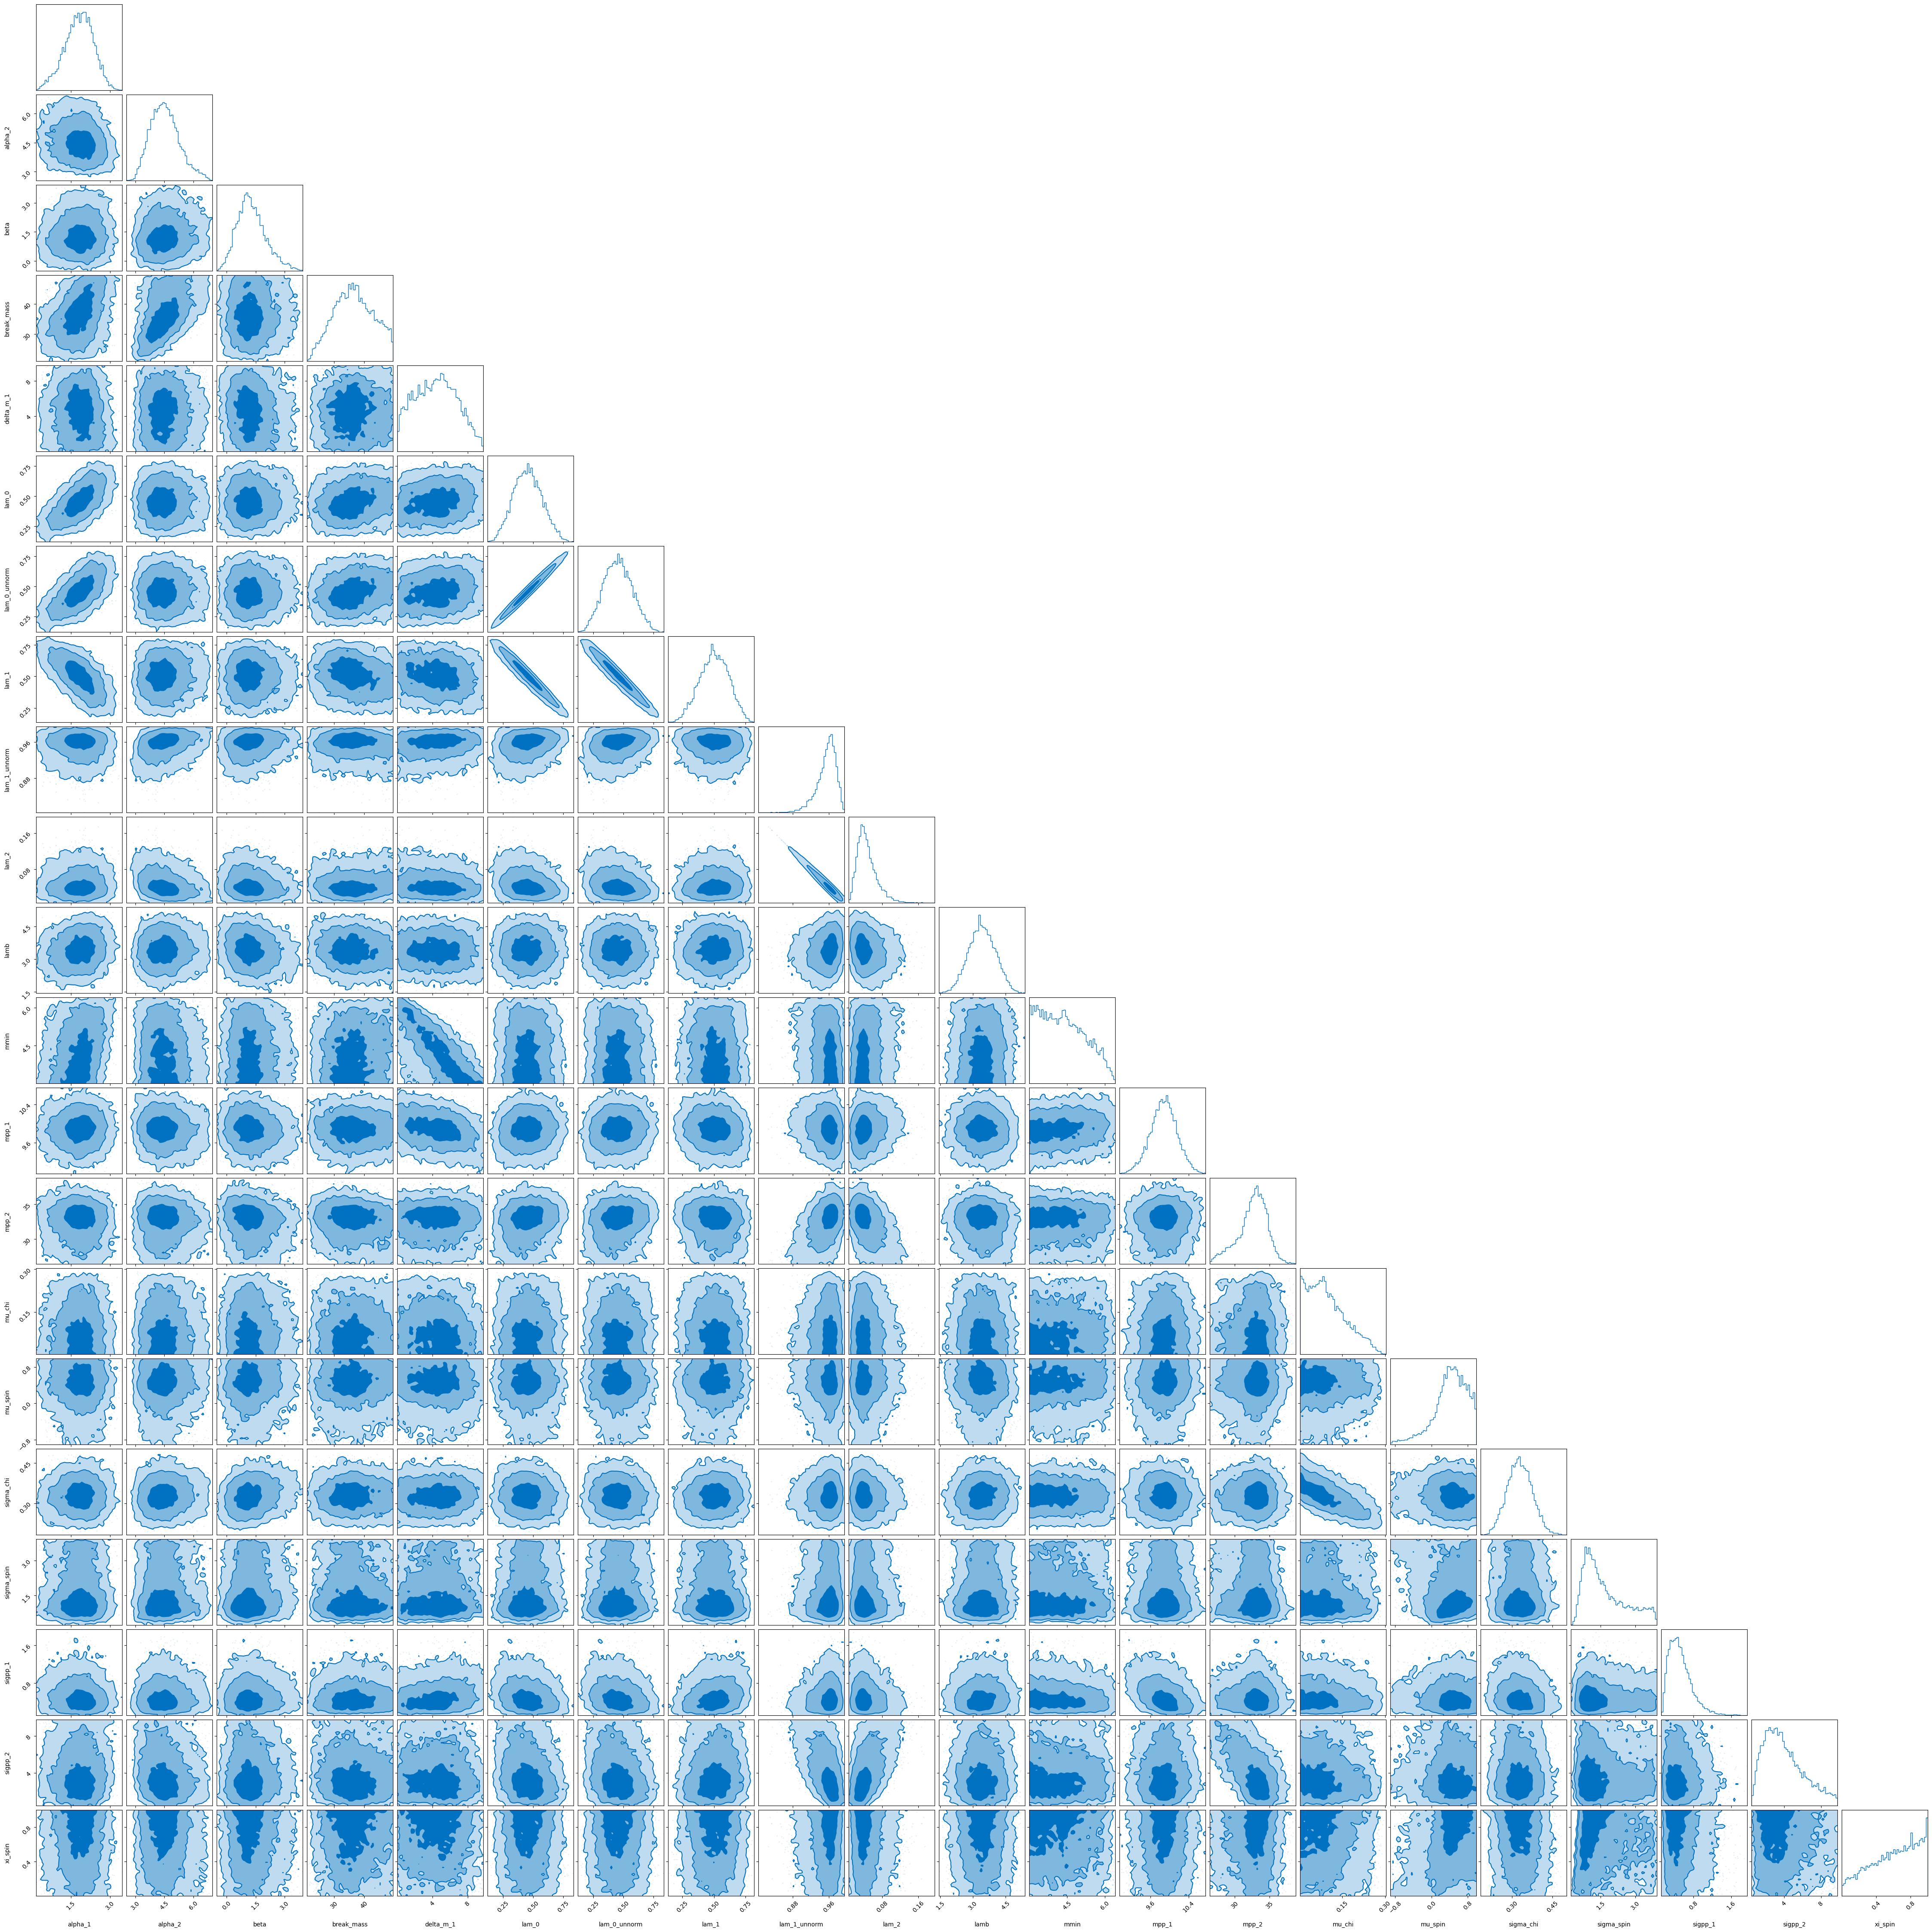

In [98]:
fig = plot_corner(samples)

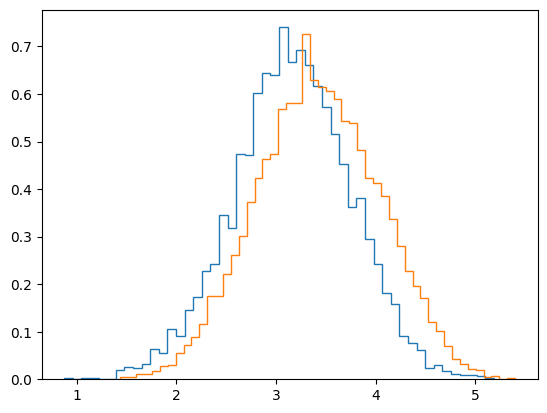

In [108]:
fig, ax = plt.subplots()

ax.hist(o4a_samples['lamb'], histtype='step', bins=50, density=True)
ax.hist(samples['lamb'], histtype='step', bins=50, density=True);

In [99]:
from jax_tqdm import scan_tqdm

@scan_tqdm(10_000)
def step(__, x):
    _, parameters = x
    lkl, var, _, _, _ = log_likelihood(parameters)
    lpr = log_prior(parameters)
    log_p = lkl + lpr
    return __, (lkl, var, lpr, log_p)

_, (lkl, var, lpr, log_p) = jax.lax.scan(step, None, (jnp.arange(10_000), samples))

Running for 10,000 iterations: 100%|██████████| 10000/10000 [01:25<00:00, 116.72it/s]


In [100]:
samples['log_q'] = log_q
samples['log_posterior'] = log_p
samples['log_likelihood'] = lkl
samples['log_prior'] = lpr
samples['variance'] = var

stats = estimate_convergence(log_p, log_q)

In [102]:
stats['eff']

Array(0.00797385, dtype=float64)